In [7]:
from shinka.utils import load_programs_to_df

path = "results/results_stlc_async_small/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 4
Correct program rows: 0
Total cost: $0.01
Avg cost per program: $0.00
Total prompt rows: 1
Prompts in archive: 1


In [8]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,novelty_attempt,resample_attempt,patch_attempt,model_name,temperature,max_output_tokens,llm_result,results_missing,safe_processing,total_cost
0,75289712-8ed9-441b-9ab6-74d3fda7a873,"from typing import Literal, Tuple\nimport rand...",python,NaN,[],[],0,2026-03-15 06:03:16.165740967,0.679,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,cae133d1-ba4b-4fa7-ade5-8b92f2f8676a,"from typing import Literal, Tuple\nimport rand...",python,75289712-8ed9-441b-9ab6-74d3fda7a873,[],[],1,2026-03-15 06:03:41.232556105,0.428,[],...,1.0,1.0,1.0,openrouter/minimax/minimax-m2.5,0.5,32768.0,{'content': ' Let me analyze the error. The er...,False,True,0.001843
2,1c2f2acc-5331-4717-9a7a-bd057bae35f8,"from typing import Literal, Tuple\nimport rand...",python,cae133d1-ba4b-4fa7-ade5-8b92f2f8676a,[75289712-8ed9-441b-9ab6-74d3fda7a873],[],3,2026-03-15 06:04:22.510721922,0.427,[],...,1.0,1.0,1.0,openrouter/minimax/minimax-m2.5,0.5,32768.0,{'content': ' Let me analyze the error output ...,False,True,0.002370
3,08828b04-5d49-4b95-87da-8872490f0d7b,"from typing import Literal, Tuple\nimport rand...",python,75289712-8ed9-441b-9ab6-74d3fda7a873,[],[],2,2026-03-15 06:04:31.646050930,0.428,[],...,1.0,1.0,2.0,openrouter/minimax/minimax-m2.5,0.0,32768.0,{'content': 'Let me analyze the error more car...,False,True,0.004587


IndexError: single positional indexer is out-of-bounds

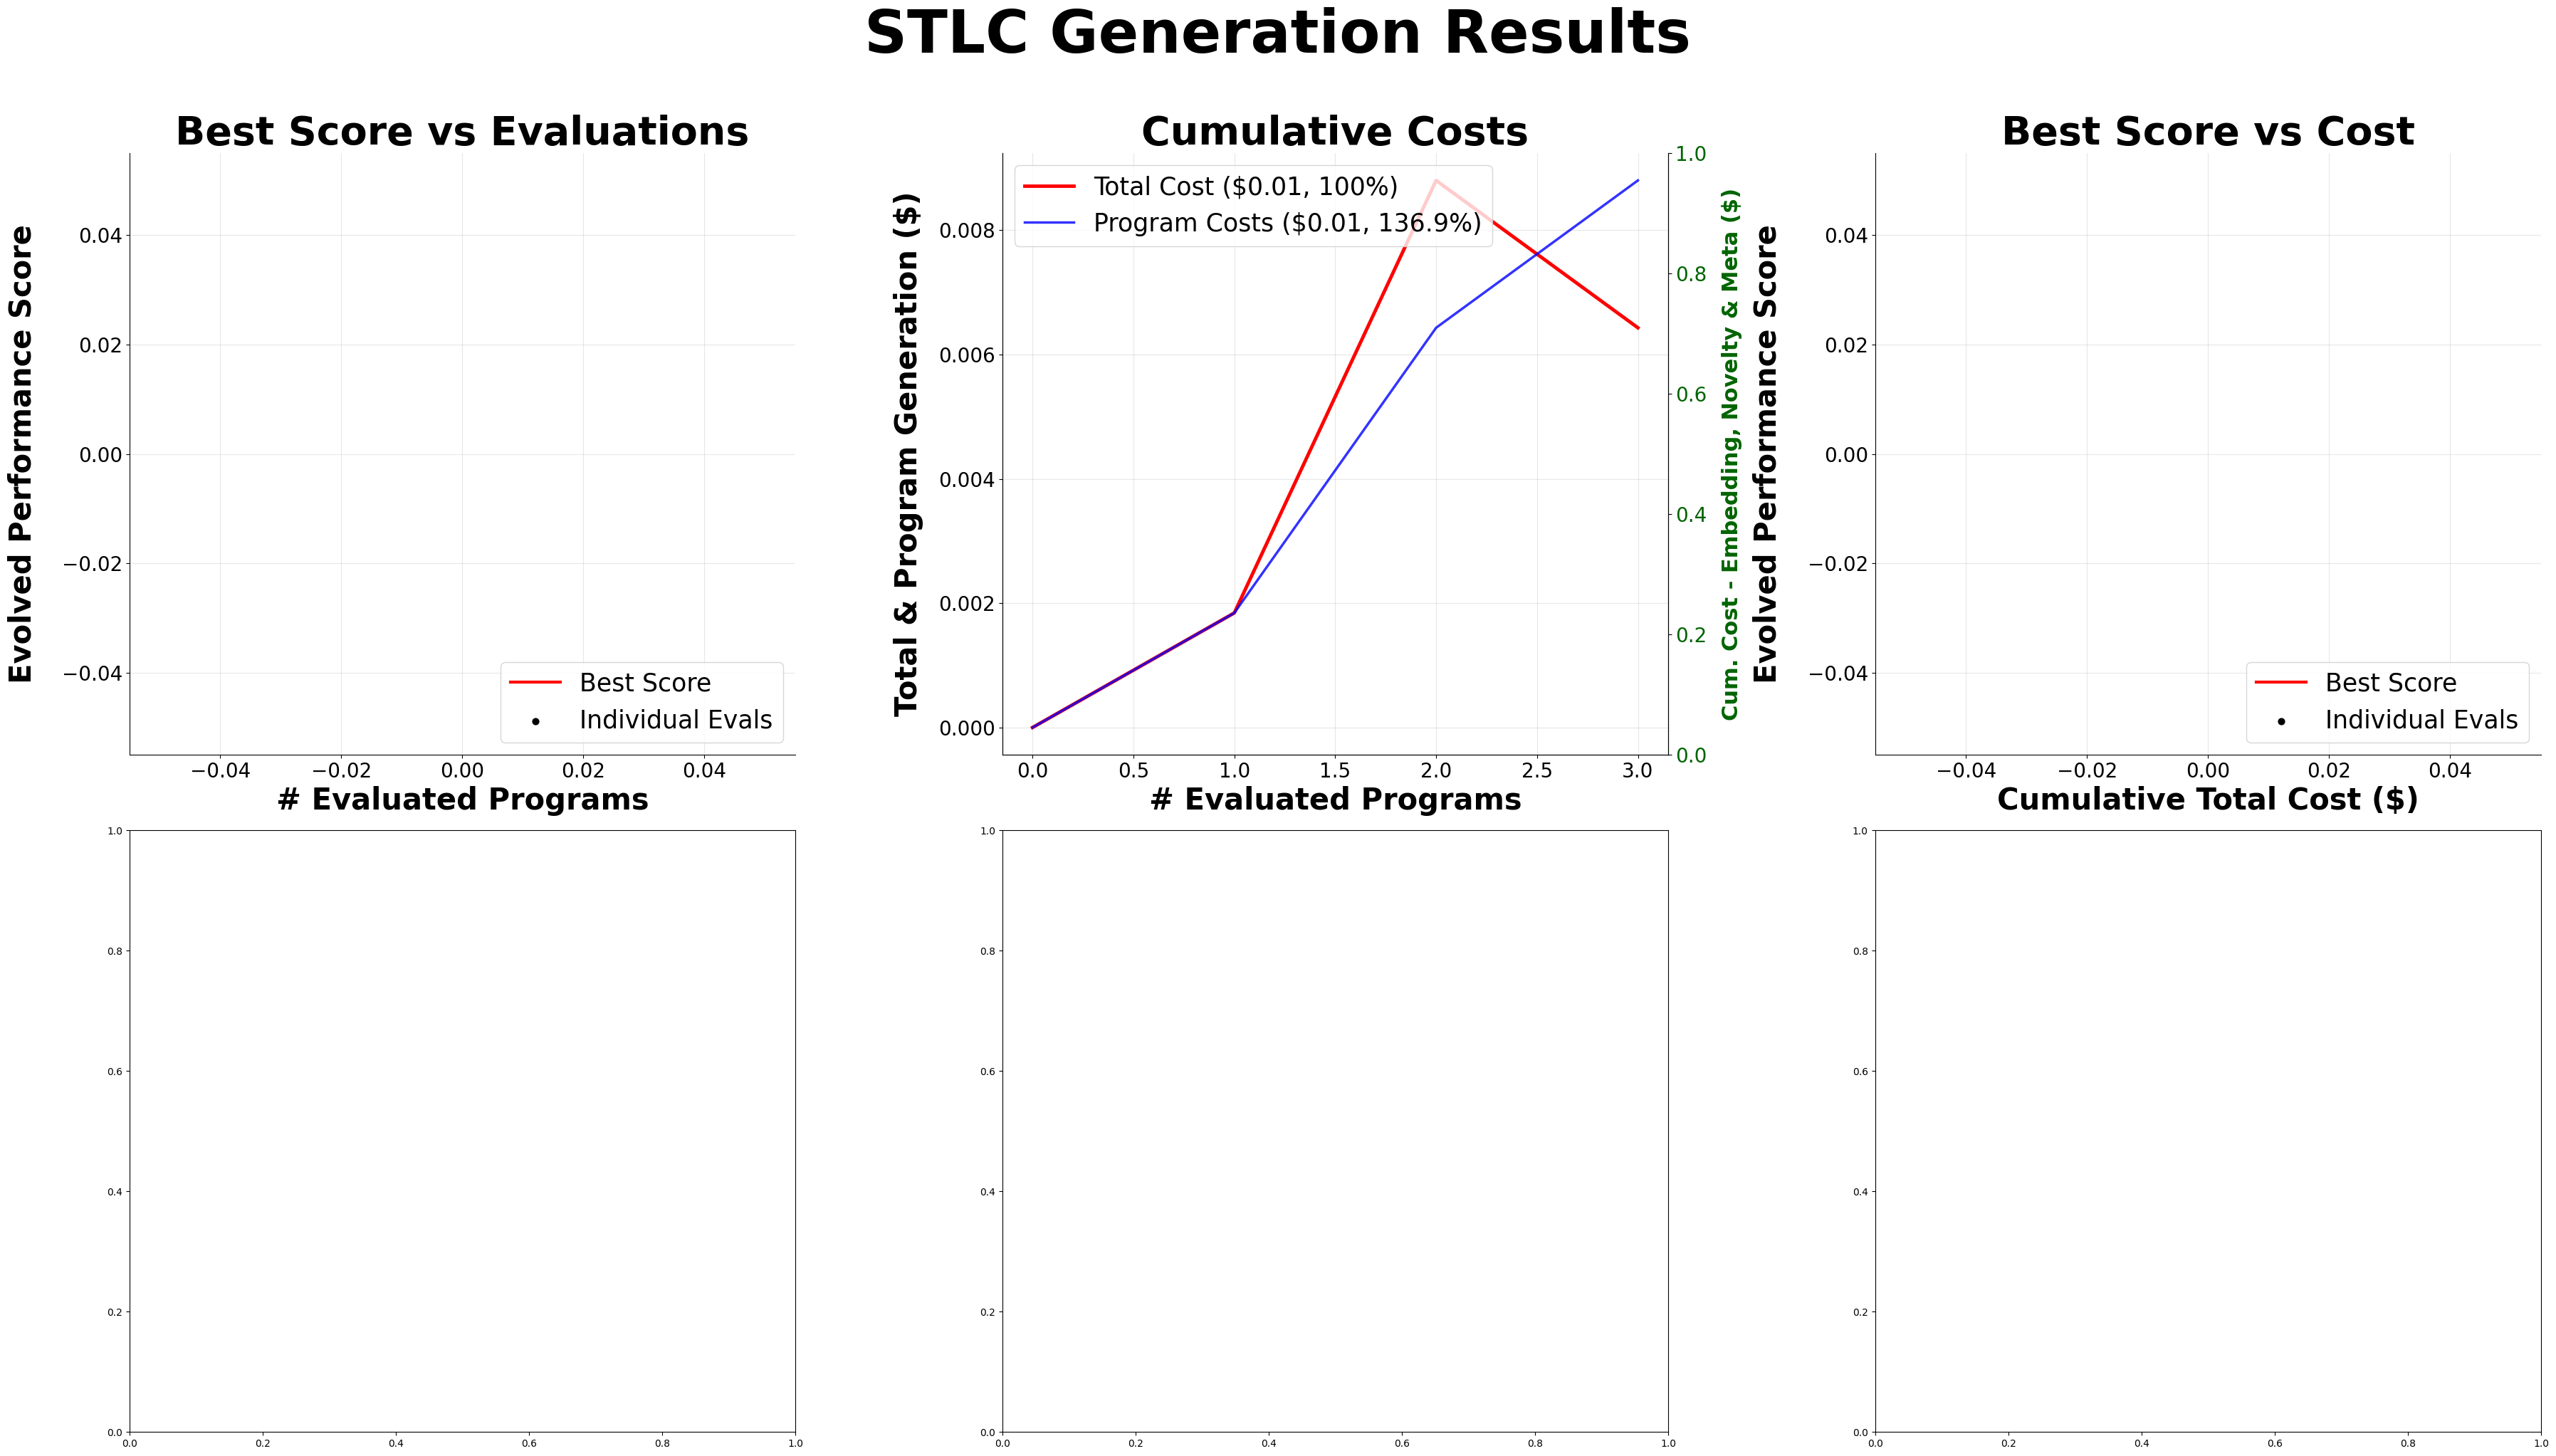

In [9]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("STLC Generation Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

plt.tight_layout()
plt.show()
